# 01 — Exploratory Data Analysis
**VitalTracker | PhysioNet BIDMC Dataset**

Goal: Understand the structure, quality, and distribution of HR and SpO2 signals
across 53 ICU patients before preprocessing and model training.

Dataset: BIDMC PPG and Respiration Dataset (physionet.org/content/bidmc/1.0.0/)  
Signals used: HR (bpm), SpO2 (%)  
Sampling rate: 1 Hz  

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'font.size'         : 11,
})

In [2]:
data = pd.read_csv("../data/raw/bidmc/bidmc_compiled_numerics.csv")

data.head()

,Time,HR,SpO2,patient_id
0,0,94.0,97.0,1
1,1,94.0,97.0,1
2,2,94.0,97.0,1
3,3,92.0,97.0,1
4,4,93.0,97.0,1


In [5]:
print(f"Total rows:     {len(data)}")
print(f"Patients:       {data['patient_id'].nunique()}")
print(f"HR range:       {data['HR'].min()} - {data['HR'].max()} bpm")
print(f"SpO2 range:     {data['SpO2'].min()} - {data['SpO2'].max()} %")
print(f"Missing values:\n{data.isnull().sum()}")

Total rows:     25493
Patients:       53
HR range:       44.0 - 139.0 bpm
SpO2 range:     83.0 - 100.0 %
Missing values:
Time            0
HR              4
SpO2          128
patient_id      0
dtype: int64


### 2. Per-Patient Record Length

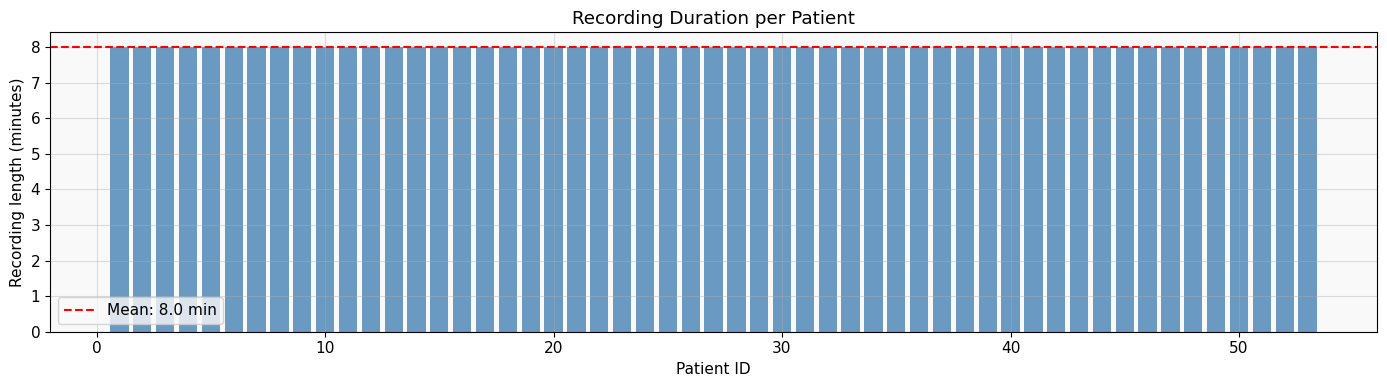

Shortest recording : 8.0 min (patient 1)
Longest recording  : 8.0 min (patient 1)
Mean recording     : 8.0 min


In [8]:
# How many seconds of data does each patient have?
record_lengths = data.groupby('patient_id').size().sort_values()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(record_lengths.index, record_lengths.values / 60, color='steelblue', alpha=0.8)
ax.axhline(record_lengths.mean() / 60, color='red', linestyle='--', label=f'Mean: {record_lengths.mean()/60:.1f} min')
ax.set_xlabel('Patient ID')
ax.set_ylabel('Recording length (minutes)')
ax.set_title('Recording Duration per Patient')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Shortest recording : {record_lengths.min()/60:.1f} min (patient {record_lengths.idxmin()})')
print(f'Longest recording  : {record_lengths.max()/60:.1f} min (patient {record_lengths.idxmax()})')
print(f'Mean recording     : {record_lengths.mean()/60:.1f} min')

### 3. Overall Signal Distributions

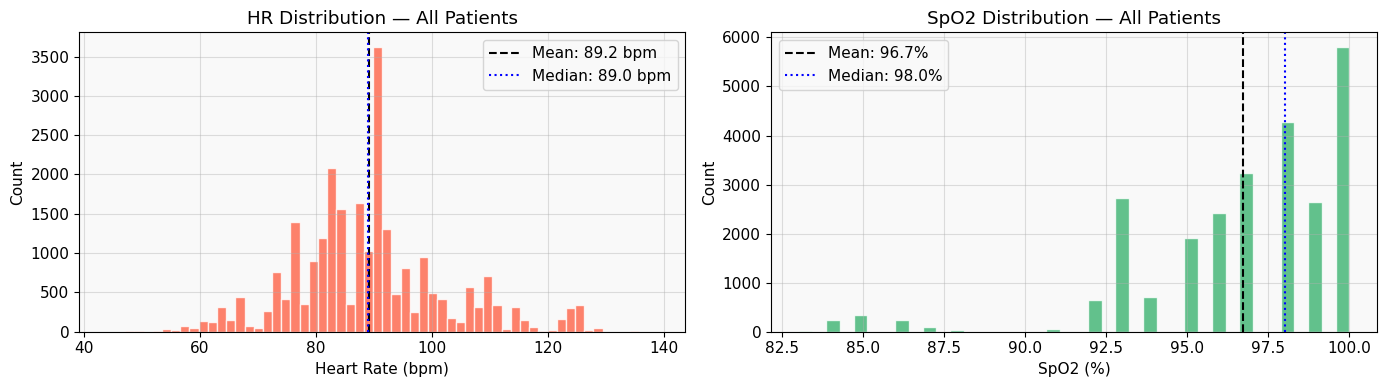

HR Statistics:
count    25489.00
mean        89.18
std         13.33
min         44.00
25%         81.00
50%         89.00
75%         95.00
max        139.00
Name: HR, dtype: float64

SpO2 Statistics:
count    25365.00
mean        96.72
std          3.30
min         83.00
25%         95.00
50%         98.00
75%         99.00
max        100.00
Name: SpO2, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# HR distribution
axes[0].hist(data['HR'].dropna(), bins=60, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(data['HR'].mean(), color='black', linestyle='--', label=f'Mean: {data["HR"].mean():.1f} bpm')
axes[0].axvline(data['HR'].median(), color='blue', linestyle=':', label=f'Median: {data["HR"].median():.1f} bpm')
axes[0].set_xlabel('Heart Rate (bpm)')
axes[0].set_ylabel('Count')
axes[0].set_title('HR Distribution — All Patients')
axes[0].legend()

# SpO2 distribution
axes[1].hist(data['SpO2'].dropna(), bins=40, color='mediumseagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(data['SpO2'].mean(), color='black', linestyle='--', label=f'Mean: {data["SpO2"].mean():.1f}%')
axes[1].axvline(data['SpO2'].median(), color='blue', linestyle=':', label=f'Median: {data["SpO2"].median():.1f}%')
axes[1].set_xlabel('SpO2 (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('SpO2 Distribution — All Patients')
axes[1].legend()

plt.tight_layout()
plt.show()

print('HR Statistics:')
print(data['HR'].describe().round(2))
print('\nSpO2 Statistics:')
print(data['SpO2'].describe().round(2))

### 4. Per-Patient HR and SpO2 Boxplots

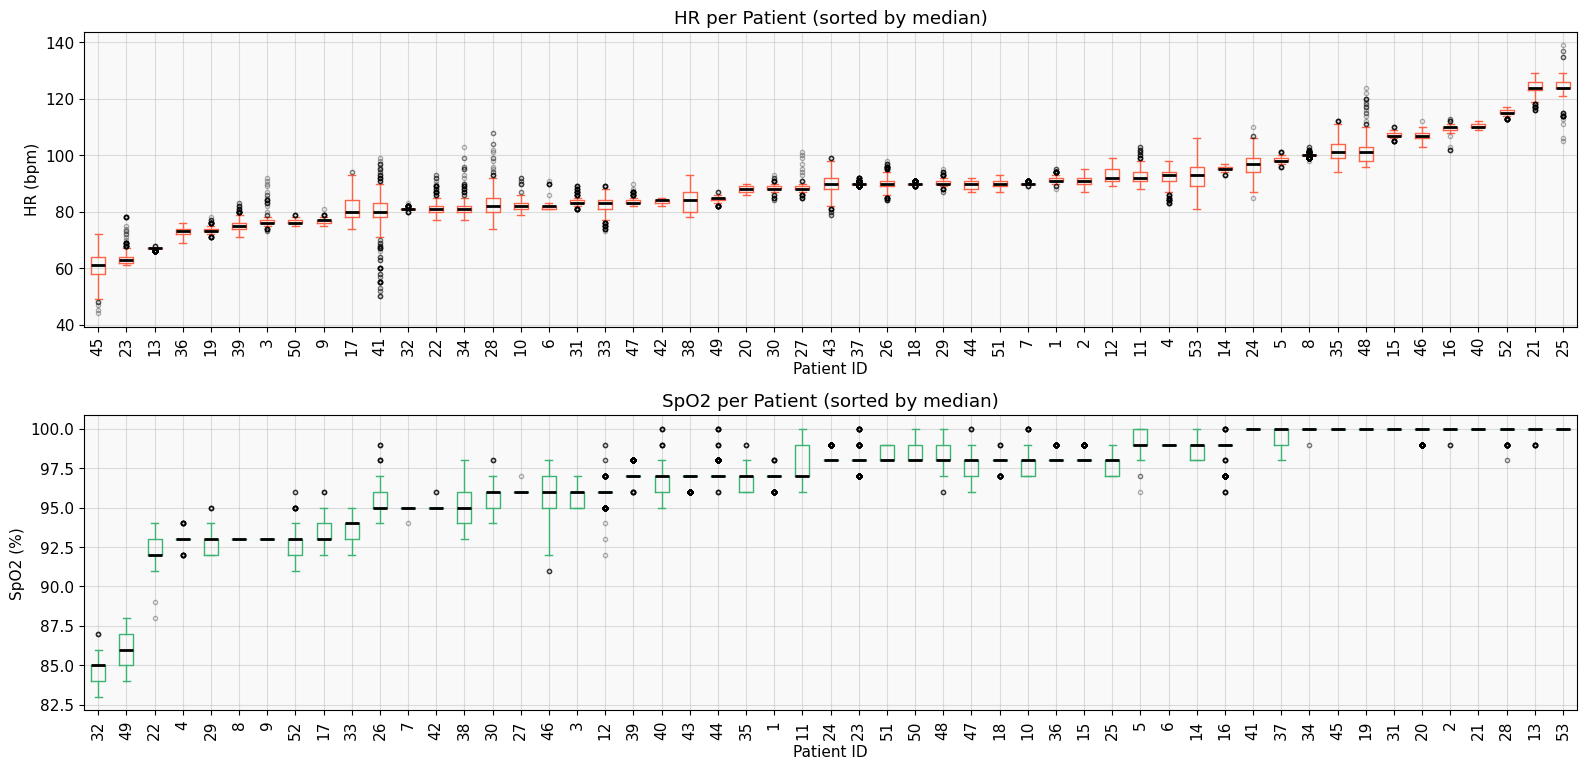

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Per-patient HR boxplot
patient_order = data.groupby('patient_id')['HR'].median().sort_values().index
df_sorted = data.copy()
df_sorted['patient_id'] = pd.Categorical(df_sorted['patient_id'], categories=patient_order, ordered=True)

df_sorted.boxplot(column='HR', by='patient_id', ax=axes[0],
                  boxprops=dict(color='tomato'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='tomato'),
                  capprops=dict(color='tomato'),
                  flierprops=dict(marker='.', color='tomato', alpha=0.3))
axes[0].set_title('HR per Patient (sorted by median)')
axes[0].set_xlabel('Patient ID')
axes[0].set_ylabel('HR (bpm)')
axes[0].tick_params(axis='x', rotation=90)
plt.sca(axes[0])
plt.title('HR per Patient (sorted by median)')

# Per-patient SpO2 boxplot
patient_order2 = data.groupby('patient_id')['SpO2'].median().sort_values().index
df_sorted2 = data.copy()
df_sorted2['patient_id'] = pd.Categorical(df_sorted2['patient_id'], categories=patient_order2, ordered=True)

df_sorted2.boxplot(column='SpO2', by='patient_id', ax=axes[1],
                   boxprops=dict(color='mediumseagreen'),
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(color='mediumseagreen'),
                   capprops=dict(color='mediumseagreen'),
                   flierprops=dict(marker='.', color='mediumseagreen', alpha=0.3))
axes[1].set_title('SpO2 per Patient (sorted by median)')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('SpO2 (%)')
axes[1].tick_params(axis='x', rotation=90)
plt.sca(axes[1])
plt.title('SpO2 per Patient (sorted by median)')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 5. Sample Time-Series — 5 Random Patients

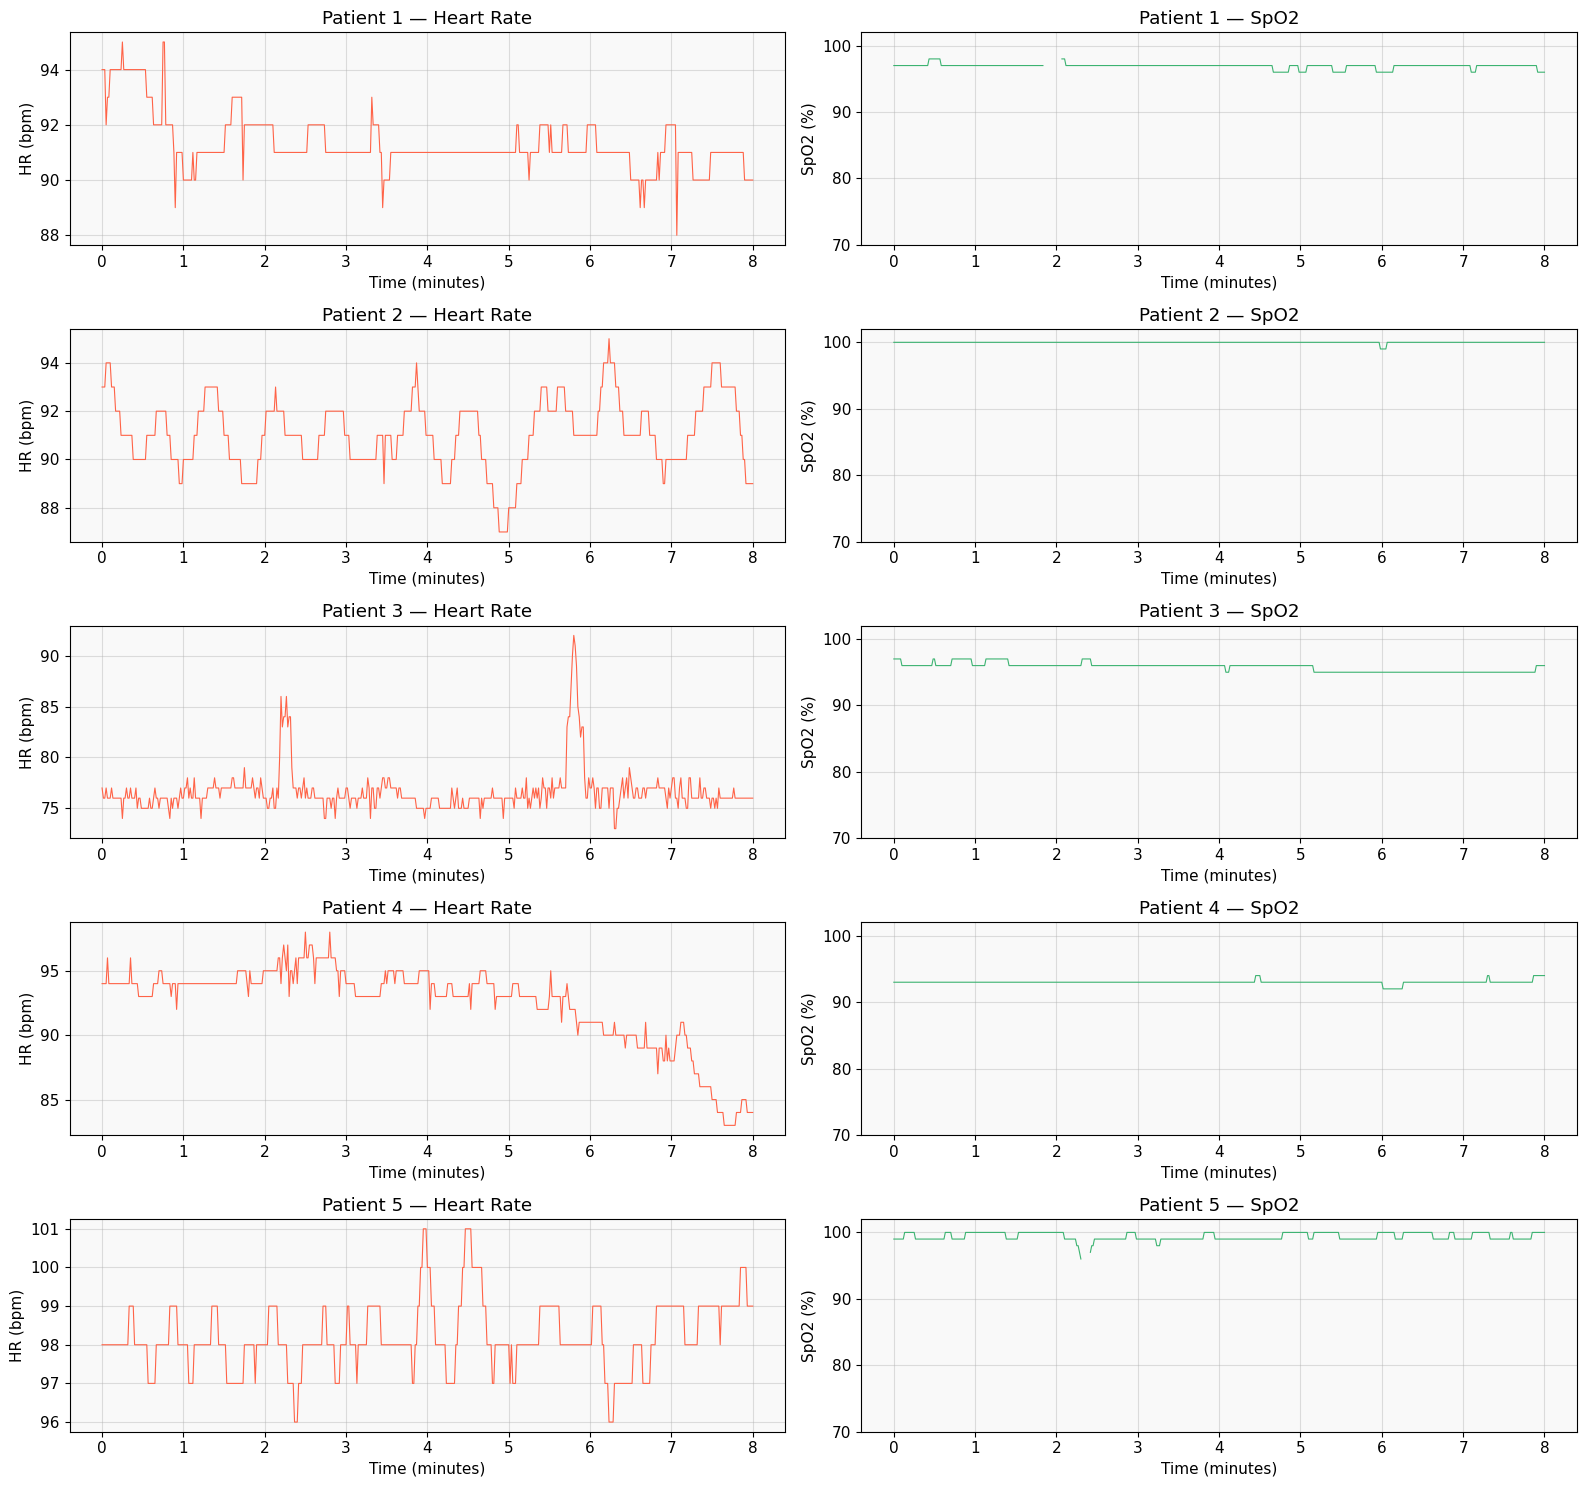

In [13]:
sample_patients = data['patient_id'].unique()[:5]

fig, axes = plt.subplots(len(sample_patients), 2, figsize=(16, 3 * len(sample_patients)))

for i, pid in enumerate(sample_patients):
    pdf = data[data['patient_id'] == pid].reset_index(drop=True)
    t   = pdf['Time'] / 60   # convert seconds to minutes

    axes[i, 0].plot(t, pdf['HR'], color='tomato', linewidth=0.8)
    axes[i, 0].set_ylabel('HR (bpm)')
    axes[i, 0].set_title(f'Patient {pid} — Heart Rate')
    axes[i, 0].set_xlabel('Time (minutes)')

    axes[i, 1].plot(t, pdf['SpO2'], color='mediumseagreen', linewidth=0.8)
    axes[i, 1].set_ylabel('SpO2 (%)')
    axes[i, 1].set_title(f'Patient {pid} — SpO2')
    axes[i, 1].set_xlabel('Time (minutes)')
    axes[i, 1].set_ylim(70, 102)

plt.tight_layout()
plt.show()

### 6. Missing Value Analysis

In [14]:
# Where are the nulls concentrated — spread across patients or clustered?
null_hr   = data[data['HR'].isnull()].groupby('patient_id').size()
null_spo2 = data[data['SpO2'].isnull()].groupby('patient_id').size()

print('Patients with missing HR readings:')
print(null_hr if len(null_hr) > 0 else '  None')

print('\nPatients with missing SpO2 readings:')
print(null_spo2 if len(null_spo2) > 0 else '  None')

# Percentage of total
print(f'\nHR null rate   : {data["HR"].isnull().sum() / len(data) * 100:.3f}%')
print(f'SpO2 null rate : {data["SpO2"].isnull().sum() / len(data) * 100:.3f}%')
print('\nConclusion: null rate is negligible — safe to drop in preprocessing.')

Patients with missing HR readings:
patient_id
27    4
dtype: int64

Patients with missing SpO2 readings:
patient_id
1      13
5       6
19    102
25      1
44      6
dtype: int64

HR null rate   : 0.016%
SpO2 null rate : 0.502%

Conclusion: null rate is negligible — safe to drop in preprocessing.


### 7. Flat-Line / Stuck Sensor Detection

In [15]:
# A stuck sensor produces identical consecutive values for many seconds
# Flag any window of 10+ identical consecutive values per patient

FLAT_WINDOW = 10

def detect_flatlines(series, window=FLAT_WINDOW):
    """Returns count of flat-line segments of length >= window."""
    count = 0
    streak = 1
    for i in range(1, len(series)):
        if series.iloc[i] == series.iloc[i-1]:
            streak += 1
            if streak == window:
                count += 1
        else:
            streak = 1
    return count

flatline_report = []
for pid, group in data.groupby('patient_id'):
    hr_flats   = detect_flatlines(group['HR'].dropna())
    spo2_flats = detect_flatlines(group['SpO2'].dropna())
    if hr_flats > 0 or spo2_flats > 0:
        flatline_report.append({'patient_id': pid, 'HR_flatlines': hr_flats, 'SpO2_flatlines': spo2_flats})

if flatline_report:
    print(f'Patients with flat-line segments (>= {FLAT_WINDOW} identical consecutive values):')
    print(pd.DataFrame(flatline_report).to_string(index=False))
else:
    print(f'No flat-line segments detected (threshold: {FLAT_WINDOW} consecutive identical values).')
print('\nNote: Some SpO2 flat-lines are physiologically normal (stable saturation at 100%).')

Patients with flat-line segments (>= 10 identical consecutive values):
 patient_id  HR_flatlines  SpO2_flatlines
          1            12              10
          2            12               2
          3             3               9
          4            11               5
          5            17              19
          6            16               1
          7            11               2
          8            12               1
          9            11               1
         10            13              15
         11             6              13
         12            15              14
         13             9               4
         14            20              15
         15            12               9
         16            12               7
         17             0              16
         18            12               7
         19             9               1
         20            11              13
         21            15               1
     

### 8. HR–SpO2 Correlation

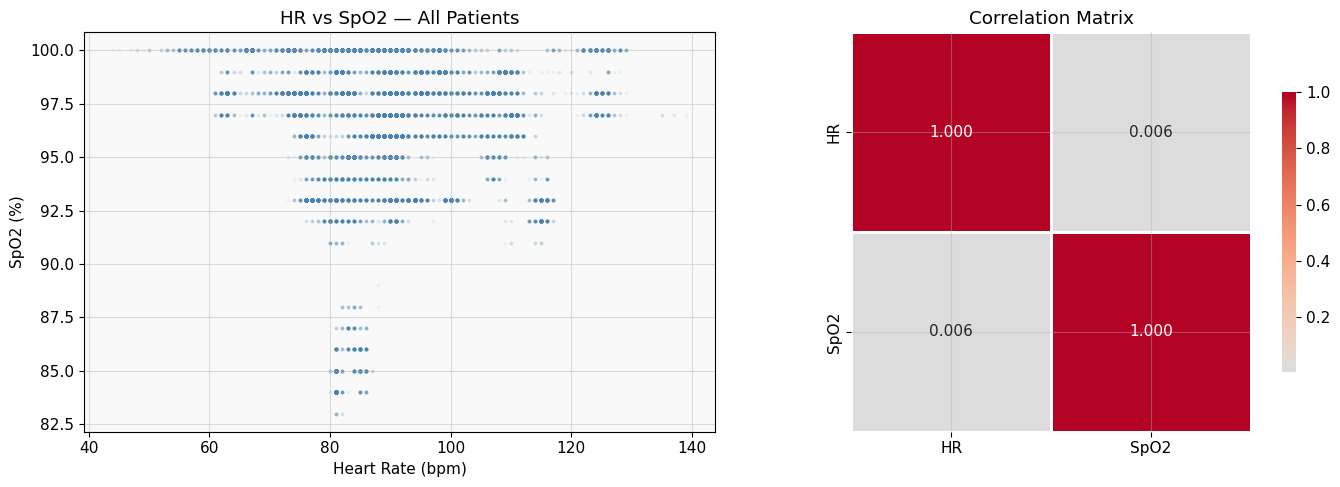

Pearson correlation (HR, SpO2): 0.0059
Low correlation is expected — they are independent physiological signals.


In [18]:
df_clean = data.dropna(subset=['HR', 'SpO2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df_clean['HR'], df_clean['SpO2'],
                alpha=0.05, s=3, color='steelblue')
axes[0].set_xlabel('Heart Rate (bpm)')
axes[0].set_ylabel('SpO2 (%)')
axes[0].set_title('HR vs SpO2 — All Patients')

# Correlation heatmap
corr = df_clean[['HR', 'SpO2']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[1], square=True,
            linewidths=1, cbar_kws={'shrink': 0.7})
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

print(f'Pearson correlation (HR, SpO2): {df_clean[["HR","SpO2"]].corr().iloc[0,1]:.4f}')
print('Low correlation is expected — they are independent physiological signals.')

## 9. Clinical Threshold Flags

Identify readings that fall into clinically abnormal ranges.  
This gives us a baseline sense of how much 'abnormal' data exists in the dataset —  
important context for the LSTM Autoencoder threshold calibration.

Clinical threshold flag counts:
---------------------------------------------
  Bradycardia (HR < 60)                 206 readings (0.81%)
  Tachycardia (HR > 100)               4108 readings (16.20%)
  Hypoxemia (SpO2 < 95%)               5082 readings (20.04%)
  Critical SpO2 (< 90%)                 964 readings (3.80%)


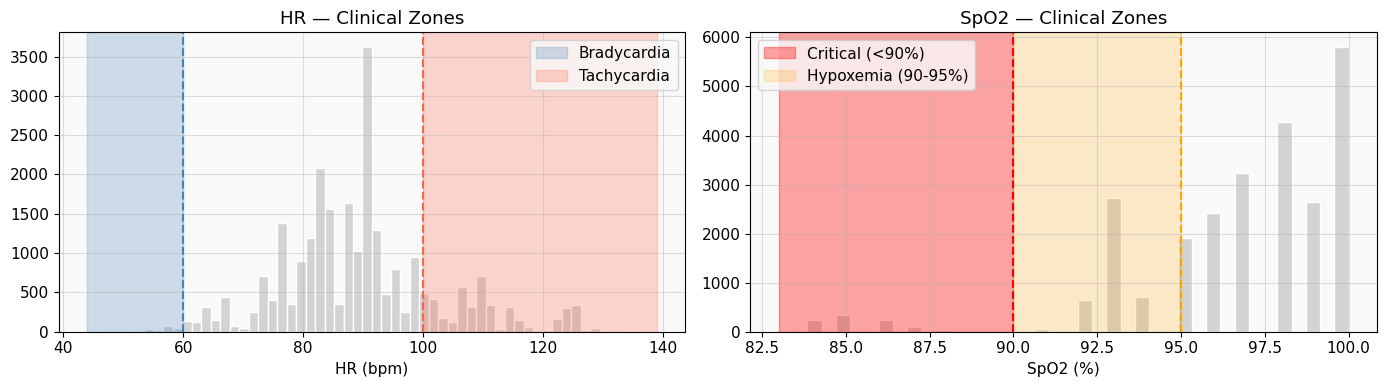

In [19]:
# Standard clinical thresholds
HR_LOW    = 60     # bradycardia below this
HR_HIGH   = 100    # tachycardia above this
SPO2_LOW  = 95     # hypoxemia below this (clinically significant)
SPO2_CRIT = 90     # critical hypoxemia below this

df_c = data.dropna(subset=['HR', 'SpO2'])

flags = {
    'Bradycardia (HR < 60)'       : (df_c['HR'] < HR_LOW).sum(),
    'Tachycardia (HR > 100)'      : (df_c['HR'] > HR_HIGH).sum(),
    'Hypoxemia (SpO2 < 95%)'      : (df_c['SpO2'] < SPO2_LOW).sum(),
    'Critical SpO2 (< 90%)'       : (df_c['SpO2'] < SPO2_CRIT).sum(),
}

print('Clinical threshold flag counts:')
print('-' * 45)
for label, count in flags.items():
    pct = count / len(df_c) * 100
    print(f'  {label:<35} {count:>5} readings ({pct:.2f}%)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# HR zones
axes[0].hist(df_c['HR'], bins=60, color='lightgrey', edgecolor='white')
axes[0].axvspan(df_c['HR'].min(), HR_LOW,  alpha=0.25, color='steelblue', label='Bradycardia')
axes[0].axvspan(HR_HIGH, df_c['HR'].max(), alpha=0.25, color='tomato',    label='Tachycardia')
axes[0].axvline(HR_LOW,  color='steelblue', linestyle='--')
axes[0].axvline(HR_HIGH, color='tomato',    linestyle='--')
axes[0].set_xlabel('HR (bpm)')
axes[0].set_title('HR — Clinical Zones')
axes[0].legend()

# SpO2 zones
axes[1].hist(df_c['SpO2'], bins=40, color='lightgrey', edgecolor='white')
axes[1].axvspan(df_c['SpO2'].min(), SPO2_CRIT, alpha=0.35, color='red',    label='Critical (<90%)')
axes[1].axvspan(SPO2_CRIT, SPO2_LOW,           alpha=0.2,  color='orange', label='Hypoxemia (90-95%)')
axes[1].axvline(SPO2_CRIT, color='red',    linestyle='--')
axes[1].axvline(SPO2_LOW,  color='orange', linestyle='--')
axes[1].set_xlabel('SpO2 (%)')
axes[1].set_title('SpO2 — Clinical Zones')
axes[1].legend()

plt.tight_layout()
plt.show()

### 10. EDA Summary & Preprocessing Notes

In [20]:
df_c = data.dropna(subset=['HR', 'SpO2'])

print('=' * 55)
print('  EDA SUMMARY — VitalTracker BIDMC Dataset')
print('=' * 55)
print(f'  Total readings     : {len(data):,}')
print(f'  Patients           : {data["patient_id"].nunique()}')
print(f'  HR range           : {data["HR"].min()} – {data["HR"].max()} bpm')
print(f'  SpO2 range         : {data["SpO2"].min()} – {data["SpO2"].max()} %')
print(f'  Missing HR         : {data["HR"].isnull().sum()} ({data["HR"].isnull().mean()*100:.3f}%)')
print(f'  Missing SpO2       : {data["SpO2"].isnull().sum()} ({data["SpO2"].isnull().mean()*100:.3f}%)')
print()
print('  PREPROCESSING PLAN (for 02_preprocessing.ipynb):')
print(f'  1. Drop rows where HR or SpO2 is null ({data["HR"].isnull().sum() + data["SpO2"].isnull().sum()} rows)')
print( '  2. Drop physiologically impossible values:')
print( '       HR < 30 or HR > 220')
print( '       SpO2 < 70 or SpO2 > 100')
print( '  3. Normalise using MinMaxScaler (fit on train split only)')
print( '  4. Sliding windows: 60-second windows, 1-step stride')
print( '  5. Train/test split: 80/20 by patient (not by row)')
print()
print('  THRESHOLD NOTES (for 04_evaluation.ipynb):')
print(f'  - SpO2 < 95% occurs in {(df_c["SpO2"] < 95).mean()*100:.1f}% of readings')
print(f'  - SpO2 < 90% occurs in {(df_c["SpO2"] < 90).mean()*100:.1f}% of readings')
print( '  - Model must maintain low false positive rate in the')
print( '    normal 95-100% SpO2 range where most readings sit.')
print('=' * 55)

  EDA SUMMARY — VitalTracker BIDMC Dataset
  Total readings     : 25,493
  Patients           : 53
  HR range           : 44.0 – 139.0 bpm
  SpO2 range         : 83.0 – 100.0 %
  Missing HR         : 4 (0.016%)
  Missing SpO2       : 128 (0.502%)

  PREPROCESSING PLAN (for 02_preprocessing.ipynb):
  1. Drop rows where HR or SpO2 is null (132 rows)
  2. Drop physiologically impossible values:
       HR < 30 or HR > 220
       SpO2 < 70 or SpO2 > 100
  3. Normalise using MinMaxScaler (fit on train split only)
  4. Sliding windows: 60-second windows, 1-step stride
  5. Train/test split: 80/20 by patient (not by row)

  THRESHOLD NOTES (for 04_evaluation.ipynb):
  - SpO2 < 95% occurs in 20.0% of readings
  - SpO2 < 90% occurs in 3.8% of readings
  - Model must maintain low false positive rate in the
    normal 95-100% SpO2 range where most readings sit.
